# COS30019 Assignment 2B — Traffic-Based Route Guidance System
## Notebook 01: Data Loading, Cleaning & Reshaping

**Purpose:** Prepare the Boroondara SCATS traffic data for downstream ML tasks.  
**Input:** Raw `.xls` files in `../data/`  
**Output:** Three artefacts in `../data/processed/` — `scats_long.parquet`, `scats_wide.parquet`, `scats_metadata.csv`

Run cells top-to-bottom. Each section ends with a short summary so you can verify correctness without reading the code.

---
## 1. Setup & File Conversion

The dataset is in legacy binary XLS format. `xlrd` 2.x reads XLS natively.  
`SCATSSiteListingSpreadsheet_VicRoads.xls` contains a corrupted named-range  
formula that causes `xlrd` to raise `AssertionError` — we monkeypatch it once  
before importing pandas so all subsequent reads are clean.

In [1]:
# stdlib
import datetime
import warnings
from pathlib import Path

# Monkeypatch xlrd BEFORE pandas imports it.
# SCATSSiteListingSpreadsheet_VicRoads.xls has a corrupted named-range
# formula that triggers AssertionError inside xlrd.book.Book.names_epilogue.
import xlrd
import xlrd.book

_orig_names_epilogue = xlrd.book.Book.names_epilogue


def _patched_names_epilogue(self):
    """Swallow AssertionError from corrupted named-range formulas; re-raise all else."""
    try:
        _orig_names_epilogue(self)
    except AssertionError:
        pass


xlrd.book.Book.names_epilogue = _patched_names_epilogue

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore", category=UserWarning, module="xlrd")

print(f"pandas {pd.__version__}  numpy {np.__version__}  xlrd {xlrd.__version__}")

pandas 3.0.2  numpy 2.4.3  xlrd 2.0.2


In [2]:
DATA_DIR      = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

SCATS_DATA_XLS  = DATA_DIR / "Scats Data October 2006.xls"
SCATS_SITES_XLS = DATA_DIR / "SCATSSiteListingSpreadsheet_VicRoads.xls"
TRAFFIC_CSV     = DATA_DIR / "Traffic_Count_Locations_with_LONG_LAT.csv"

for path in [SCATS_DATA_XLS, SCATS_SITES_XLS, TRAFFIC_CSV]:
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {path.name}")

  [OK] Scats Data October 2006.xls
  [OK] SCATSSiteListingSpreadsheet_VicRoads.xls
  [OK] Traffic_Count_Locations_with_LONG_LAT.csv


---
## 2. Load Raw Data

**Sheet:** `Data` in `Scats Data October 2006.xls`  
**Header row:** spreadsheet row 2 = `header=1` in pandas (zero-indexed).  
Row 1 of the sheet is a merged label over the V00-V95 block; row 2 has the real column names.

Expected shape: 4192 rows x 106 columns (10 metadata + 96 volume intervals).

In [3]:
raw_df = pd.read_excel(
    SCATS_DATA_XLS,
    sheet_name="Data",
    header=1,        # row index 1 holds the real column names
    engine="xlrd",
)

EXPECTED_ROWS       = 4192
EXPECTED_SCATS      = 40
EXPECTED_APPROACHES = 139
N_INTERVALS         = 96   # V00-V95 fifteen-minute bins per day

assert raw_df.shape[0] == EXPECTED_ROWS, (
    f"Expected {EXPECTED_ROWS} rows, got {raw_df.shape[0]}"
)

print(f"Shape: {raw_df.shape}")
print(f"\nColumn names (first 12): {raw_df.columns[:12].tolist()}")
print(f"Column names (last 5):  {raw_df.columns[-5:].tolist()}")
print("\nDtypes (first 12):")
print(raw_df.dtypes[:12])
raw_df.head(3)

Shape: (4192, 106)

Column names (first 12): ['SCATS Number', 'Location', 'CD_MELWAY', 'NB_LATITUDE', 'NB_LONGITUDE', 'HF VicRoads Internal', 'VR Internal Stat', 'VR Internal Loc', 'NB_TYPE_SURVEY', 'Date', 'V00', 'V01']
Column names (last 5):  ['V91', 'V92', 'V93', 'V94', 'V95']

Dtypes (first 12):
SCATS Number                     int64
Location                           str
CD_MELWAY                          str
NB_LATITUDE                    float64
NB_LONGITUDE                   float64
HF VicRoads Internal             int64
VR Internal Stat                 int64
VR Internal Loc                  int64
NB_TYPE_SURVEY                   int64
Date                    datetime64[us]
V00                              int64
V01                              int64
dtype: object


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95
0,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01 00:15:00,...,114,97,97,66,81,50,59,47,29,34
1,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02 00:15:00,...,111,102,107,114,80,60,62,48,44,26
2,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03 00:15:00,...,130,132,114,86,93,90,73,57,29,40


In [4]:
n_scats      = raw_df["SCATS Number"].nunique()
n_approaches = raw_df.groupby(["SCATS Number", "Location"]).ngroups

assert n_scats == EXPECTED_SCATS, (
    f"Expected {EXPECTED_SCATS} unique SCATS Numbers, found {n_scats}"
)
assert n_approaches == EXPECTED_APPROACHES, (
    f"Expected {EXPECTED_APPROACHES} (SCATS, Location) pairs, found {n_approaches}"
)

print(f"Unique SCATS Numbers (intersections): {n_scats}  OK")
print(f"Unique (SCATS Number, Location) pairs: {n_approaches}  OK")
print(f"\nSample SCATS Numbers: {sorted(raw_df['SCATS Number'].unique())[:8]}")

Unique SCATS Numbers (intersections): 40  OK
Unique (SCATS Number, Location) pairs: 139  OK

Sample SCATS Numbers: [np.int64(970), np.int64(2000), np.int64(2200), np.int64(2820), np.int64(2825), np.int64(2827), np.int64(2846), np.int64(3001)]


### 2.1 Load SCATS Site Reference Catalogue (optional lookup)

In [5]:
# xlrd monkeypatch (cell 1) is already active; this loads without error.
sites_df = pd.read_excel(
    SCATS_SITES_XLS,
    sheet_name="SCATS Site Numbers",
    header=9,   # real header on row index 9 (tenth row)
    engine="xlrd",
)
sites_df["Site Number"] = sites_df["Site Number"].astype("Int64")
print(f"SCATS site catalogue: {sites_df.shape[0]} entries")
sites_df.head(3)

*** formula/tFunc unknown FuncID:186
*** formula/tFunc unknown FuncID:186
*** formula/tFunc unknown FuncID:186
*** formula/tFunc unknown FuncID:186
*** formula/tFunc unknown FuncID:186
*** formula/tFunc unknown FuncID:186
SCATS site catalogue: 4515 entries


,Site Number,Location Description,Site Type,Directory,Map reference
0,964,ABBOTTS/CLELANDS DEVELOPMENTS,INT,Melway,095G08
1,968,ABBOTTS/GAINE/MONASH,INT,Melway,095K08
2,972,ABBOTTS/NATIONAL,INT,Melway,95J08


### 2.2 Traffic Count Locations (optional research extension)

In [6]:
# Not used in the main pipeline. Uncomment for geographic extensions.
# traffic_locations_df = pd.read_csv(TRAFFIC_CSV)
# print(traffic_locations_df.shape)
# traffic_locations_df.head(3)

---
## 3. Clean

Steps:
1. Strip the time component from `Date` (stored as `2006-10-01 00:15:00` — the time is an XLS serial artefact).
2. Normalise `SCATS Number` to `int`.
3. Fix `NB_LATITUDE == 0` / `NB_LONGITUDE == 0` for site 4266.  One approach (`AUBURN_RD N of BURWOOD_RD`) has all 31 rows at (0, 0).  Fill using the modal non-zero coordinate across the site's other approaches.  Volume data is retained — the rows are valid traffic observations.
4. Verify no V00-V95 column is entirely null for any single approach.

In [7]:
clean_df = raw_df.copy()

# Strip time-of-day artefact; keep only the date.
clean_df["Date"] = pd.to_datetime(clean_df["Date"]).dt.date
print("Date dtype after strip:", clean_df["Date"].dtype)
print("Date sample:", clean_df["Date"].iloc[:3].tolist())

Date dtype after strip: object
Date sample: [datetime.date(2006, 10, 1), datetime.date(2006, 10, 2), datetime.date(2006, 10, 3)]


In [8]:
# xlrd already reads SCATS Number as int64; cast is explicit for safety.
clean_df["SCATS Number"] = clean_df["SCATS Number"].astype(int)
print("SCATS Number dtype:", clean_df["SCATS Number"].dtype)

SCATS Number dtype: int64


In [9]:
def fill_zero_coords(df: pd.DataFrame) -> pd.DataFrame:
    """Replace (0, 0) lat/lon sentinel values with the modal non-zero
    coordinate for the same SCATS site number.

    In this dataset, coordinates of exactly 0 are unambiguously sentinels:
    all intersections are in Melbourne, nowhere near null-island.
    A missing approach is filled from the mode across the site's other approaches.
    If the entire site lacks valid coords, rows are set to NaN and a
    warning is emitted; volume data is still retained.

    Args:
        df: DataFrame with columns SCATS Number, NB_LATITUDE, NB_LONGITUDE.

    Returns:
        A copy of df with zero coords replaced.
    """
    df = df.copy()
    zero_mask = (df["NB_LATITUDE"] == 0) | (df["NB_LONGITUDE"] == 0)
    affected_sites = df.loc[zero_mask, "SCATS Number"].unique()

    for site in affected_sites:
        site_mask  = df["SCATS Number"] == site
        valid_mask = site_mask & ~zero_mask
        fill_lat = (
            df.loc[valid_mask, "NB_LATITUDE"].mode()
            if valid_mask.any() else pd.Series(dtype=float)
        )
        fill_lon = (
            df.loc[valid_mask, "NB_LONGITUDE"].mode()
            if valid_mask.any() else pd.Series(dtype=float)
        )
        site_zero_mask = site_mask & zero_mask
        n_affected = site_zero_mask.sum()

        if fill_lat.empty or fill_lon.empty:
            warnings.warn(
                f"Site {site}: {n_affected} rows have (0,0) coords and no "
                f"non-zero reference exists for this site -- coords set to NaN."
            )
            df.loc[site_zero_mask, ["NB_LATITUDE", "NB_LONGITUDE"]] = np.nan
        else:
            df.loc[site_zero_mask, "NB_LATITUDE"]  = fill_lat.iloc[0]
            df.loc[site_zero_mask, "NB_LONGITUDE"] = fill_lon.iloc[0]
            print(
                f"Site {site}: filled {n_affected} rows (0,0) -> "
                f"({fill_lat.iloc[0]:.5f}, {fill_lon.iloc[0]:.5f})"
            )

    remaining_zeros = (
        (df["NB_LATITUDE"] == 0) | (df["NB_LONGITUDE"] == 0)
    ).sum()
    assert remaining_zeros == 0, (
        f"{remaining_zeros} rows still have (0,0) coords after fill"
    )
    return df


clean_df = fill_zero_coords(clean_df)
still_zero = ((clean_df["NB_LATITUDE"] == 0) | (clean_df["NB_LONGITUDE"] == 0)).sum()
print(f"Rows with (0,0) coords after fix: {still_zero}  OK")

Site 4266: filled 31 rows (0,0) -> (-37.82542, 145.04301)
Rows with (0,0) coords after fix: 0  OK


In [10]:
v_cols = [col for col in clean_df.columns if col.startswith("V") and col[1:].isdigit()]
assert len(v_cols) == N_INTERVALS, (
    f"Expected {N_INTERVALS} volume columns, found {len(v_cols)}"
)

entirely_null = (
    clean_df.groupby(["SCATS Number", "Location"])[v_cols]
    .apply(lambda g: g.isnull().all(axis=0).any())
)
n_bad = entirely_null.sum()
assert n_bad == 0, (
    f"{n_bad} approaches have at least one V column entirely null"
)
print(f"All {N_INTERVALS} V columns have at least some data per approach  OK")

All 96 V columns have at least some data per approach  OK


In [11]:
days_per_approach = (
    clean_df.groupby(["SCATS Number", "Location"])["Date"]
    .nunique()
    .rename("n_days")
)
print("Days per approach summary:")
print(days_per_approach.describe().to_string())
print(f"\nApproaches with <31 days: {(days_per_approach < 31).sum()}")
print(f"Approaches with 31 days:  {(days_per_approach == 31).sum()}")
print("\nIncomplete approaches are NOT dropped; long format handles ragged series.")

Days per approach summary:
count    139.000000
mean      29.935252
std        3.034126
min        2.000000
25%       31.000000
50%       31.000000
75%       31.000000
max       31.000000

Approaches with <31 days: 34
Approaches with 31 days:  105

Incomplete approaches are NOT dropped; long format handles ragged series.


---
## 4. Reshape to Long Format

Melt the 96 volume columns into a tidy long DataFrame.

| Column | Description |
|---|---|
| `scats_number` | Integer intersection ID |
| `location` | Approach string |
| `latitude` | Decimal degrees |
| `longitude` | Decimal degrees |
| `date` | `datetime.date` |
| `interval` | Integer 0-95 (V00=0, V95=95) |
| `time_of_day` | `datetime.time` derived from interval x 15 min |
| `timestamp` | Full `datetime` = date + interval x 15 min |
| `volume` | Vehicle count in that 15-minute window |

Primary sort key: `(scats_number, location, timestamp)`.

In [12]:
METADATA_COLS = ["SCATS Number", "Location", "NB_LATITUDE", "NB_LONGITUDE", "Date"]

long_df = (
    clean_df[METADATA_COLS + v_cols]
    .melt(
        id_vars=METADATA_COLS,
        value_vars=v_cols,
        var_name="v_col",
        value_name="volume",
    )
)

# Derive integer interval index: V00 -> 0, V95 -> 95
long_df["interval"] = long_df["v_col"].str[1:].astype(int)
long_df.drop(columns=["v_col"], inplace=True)


def interval_to_time(interval: int) -> datetime.time:
    """Convert a 15-minute interval index (0-95) to a datetime.time object."""
    total_minutes = interval * 15
    return datetime.time(hour=total_minutes // 60, minute=total_minutes % 60)


long_df["time_of_day"] = long_df["interval"].map(interval_to_time)

long_df["timestamp"] = pd.to_datetime(
    long_df["Date"].astype(str) + " " + long_df["time_of_day"].astype(str)
)

long_df.rename(
    columns={
        "SCATS Number": "scats_number",
        "Location":     "location",
        "NB_LATITUDE":  "latitude",
        "NB_LONGITUDE": "longitude",
        "Date":         "date",
    },
    inplace=True,
)

long_df = long_df[
    ["scats_number", "location", "latitude", "longitude",
     "date", "interval", "time_of_day", "timestamp", "volume"]
]

long_df.sort_values(["scats_number", "location", "timestamp"], inplace=True)
long_df.reset_index(drop=True, inplace=True)

expected_long_rows = EXPECTED_ROWS * N_INTERVALS
assert long_df.shape[0] == expected_long_rows, (
    f"Expected {expected_long_rows:,} rows, got {long_df.shape[0]:,}"
)
print(f"Long format shape: {long_df.shape}")
print(f"Expected rows: {EXPECTED_ROWS} x {N_INTERVALS} = {expected_long_rows:,}  OK")
long_df.head(5)

Long format shape: (402432, 9)
Expected rows: 4192 x 96 = 402,432  OK


,scats_number,location,latitude,longitude,date,interval,time_of_day,timestamp,volume
0,970,HIGH STREET_RD E of WARRIGAL_RD,-37.86735,145.09195,2006-10-01,0,00:00:00,2006-10-01 00:00:00,37
1,970,HIGH STREET_RD E of WARRIGAL_RD,-37.86735,145.09195,2006-10-01,1,00:15:00,2006-10-01 00:15:00,30
2,970,HIGH STREET_RD E of WARRIGAL_RD,-37.86735,145.09195,2006-10-01,2,00:30:00,2006-10-01 00:30:00,26
3,970,HIGH STREET_RD E of WARRIGAL_RD,-37.86735,145.09195,2006-10-01,3,00:45:00,2006-10-01 00:45:00,29
4,970,HIGH STREET_RD E of WARRIGAL_RD,-37.86735,145.09195,2006-10-01,4,01:00:00,2006-10-01 01:00:00,14


In [13]:
print("Long format dtypes:")
print(long_df.dtypes)
print("\nVolume stats:")
print(long_df["volume"].describe())

Long format dtypes:
scats_number             int64
location                   str
latitude               float64
longitude              float64
date                    object
interval                 int64
time_of_day             object
timestamp       datetime64[us]
volume                   int64
dtype: object

Volume stats:
count    402432.000000
mean        103.980794
std          86.716694
min           0.000000
25%          26.000000
50%          93.000000
75%         156.000000
max         695.000000
Name: volume, dtype: float64


---
## 5. Reshape to Per-Approach Time Series (Wide)

Pivot the long format so each column is one `(scats_number, location)` approach  
and the index is `timestamp`. This is the shape most ML time-series libraries expect.

A companion list `approach_ids` holds `(scats_number, location)` tuples in column  
order so any single series can be retrieved by index without string parsing.

In [14]:
# Build a composite column key that survives the pivot.
long_df["approach_key"] = (
    long_df["scats_number"].astype(str) + "__" + long_df["location"]
)

wide_df = long_df.pivot_table(
    index="timestamp",
    columns="approach_key",
    values="volume",
    aggfunc="first",
)
wide_df.columns.name = None  # drop axis label for cleaner display
wide_df.sort_index(inplace=True)

approach_ids = [
    (int(col.split("__")[0]), col.split("__", 1)[1])
    for col in wide_df.columns
]

long_df.drop(columns=["approach_key"], inplace=True)

assert wide_df.shape[1] == EXPECTED_APPROACHES, (
    f"Expected {EXPECTED_APPROACHES} approach columns, got {wide_df.shape[1]}"
)
print(f"Wide format shape: {wide_df.shape}")
print(f"  Rows (timestamps):    {wide_df.shape[0]}")
print(f"  Columns (approaches): {wide_df.shape[1]}  OK")
print(f"\nFirst 3 column keys: {wide_df.columns[:3].tolist()}")

Wide format shape: (2976, 139)
  Rows (timestamps):    2976
  Columns (approaches): 139  OK

First 3 column keys: ['2000__BURWOOD_HWY E of WARRIGAL_RD', '2000__TOORAK_RD W of WARRIGAL_RD', '2000__WARRIGAL_RD N of TOORAK_RD']


In [15]:
def get_approach_series(
    wide: pd.DataFrame,
    ids: list,
    scats_number: int,
    location: str,
) -> pd.Series:
    """Retrieve the volume time series for a single (scats_number, location) approach.

    Args:
        wide:         Wide DataFrame with composite approach keys as columns.
        ids:          List of (scats_number, location) tuples in column order.
        scats_number: Integer SCATS site number.
        location:     Exact location string as it appears in the raw data.

    Returns:
        pd.Series indexed by timestamp, values are vehicle volume counts.

    Raises:
        ValueError: If (scats_number, location) is not in ids.
    """
    key = (scats_number, location)
    if key not in ids:
        raise ValueError(f"{key} not found in approach_ids")
    return wide.iloc[:, ids.index(key)]


demo_series = get_approach_series(
    wide_df, approach_ids,
    scats_number=970,
    location="WARRIGAL_RD N of HIGH STREET_RD",
)
print("Example: SCATS 970 / WARRIGAL_RD N of HIGH STREET_RD")
print(f"  Length: {len(demo_series)}  non-null: {demo_series.notna().sum()}")
demo_series.head(6)

Example: SCATS 970 / WARRIGAL_RD N of HIGH STREET_RD
  Length: 2976  non-null: 2976


timestamp
2006-10-01 00:00:00    86.0
2006-10-01 00:15:00    83.0
2006-10-01 00:30:00    52.0
2006-10-01 00:45:00    58.0
2006-10-01 01:00:00    59.0
2006-10-01 01:15:00    44.0
Name: 970__WARRIGAL_RD N of HIGH STREET_RD, dtype: float64

---
## 6. Sanity-Check Plots

Three plots to confirm the data looks like real traffic before any modelling.

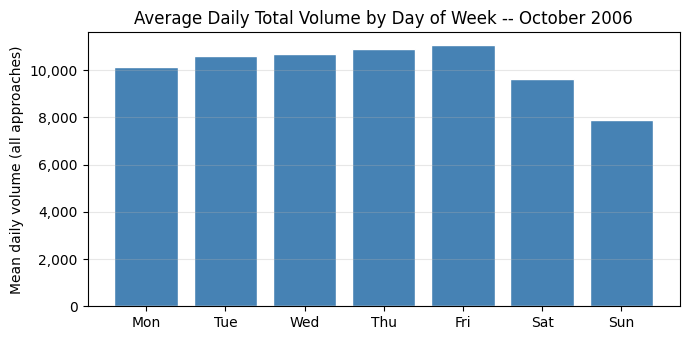

Day-of-week averages:
  Mon: 10,123
  Tue: 10,606
  Wed: 10,698
  Thu: 10,887
  Fri: 11,047
  Sat: 9,625
  Sun: 7,876


In [16]:
# 6.1 Average daily total volume by day of week
daily_totals = (
    long_df.groupby(["scats_number", "location", "date"])["volume"]
    .sum()
    .reset_index()
)
daily_totals["dow"] = pd.to_datetime(daily_totals["date"]).dt.dayofweek

avg_by_dow = daily_totals.groupby("dow")["volume"].mean()
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(avg_by_dow.index, avg_by_dow.values, color="steelblue", edgecolor="white")
ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
ax.set_ylabel("Mean daily volume (all approaches)")
ax.set_title("Average Daily Total Volume by Day of Week -- October 2006")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig(PROCESSED_DIR / "plot_dow_volume.png", dpi=120)
plt.show()

print("Day-of-week averages:")
for dow, label in enumerate(day_labels):
    print(f"  {label}: {avg_by_dow.get(dow, 0):,.0f}")

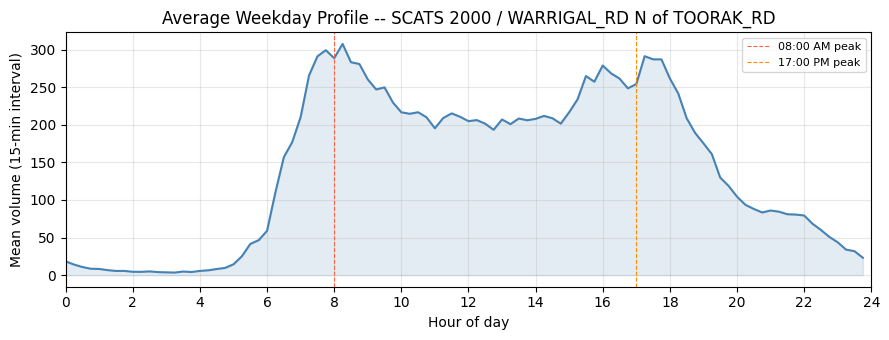

In [17]:
# 6.2 Average weekday 24-hour profile for site 2000
TARGET_SCATS    = 2000
TARGET_LOCATION = "WARRIGAL_RD N of TOORAK_RD"

approach_long = long_df[
    (long_df["scats_number"] == TARGET_SCATS) &
    (long_df["location"] == TARGET_LOCATION)
]
if approach_long.empty:
    available = long_df[long_df["scats_number"] == TARGET_SCATS]["location"].unique()
    TARGET_LOCATION = available[0]
    print(f"Location not found; falling back to: {TARGET_LOCATION}")
    approach_long = long_df[
        (long_df["scats_number"] == TARGET_SCATS) &
        (long_df["location"] == TARGET_LOCATION)
    ]

weekday_profile = (
    approach_long[pd.to_datetime(approach_long["date"]).dt.dayofweek < 5]
    .groupby("interval")["volume"]
    .mean()
)
x_hours = [i * 15 / 60 for i in weekday_profile.index]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(x_hours, weekday_profile.values, color="steelblue", linewidth=1.5)
ax.fill_between(x_hours, weekday_profile.values, alpha=0.15, color="steelblue")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean volume (15-min interval)")
ax.set_title(f"Average Weekday Profile -- SCATS {TARGET_SCATS} / {TARGET_LOCATION}")
ax.set_xticks(range(0, 25, 2))
ax.set_xlim(0, 24)
ax.axvline(8,  color="tomato",     linestyle="--", linewidth=0.8, label="08:00 AM peak")
ax.axvline(17, color="darkorange", linestyle="--", linewidth=0.8, label="17:00 PM peak")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig(PROCESSED_DIR / "plot_weekday_profile.png", dpi=120)
plt.show()

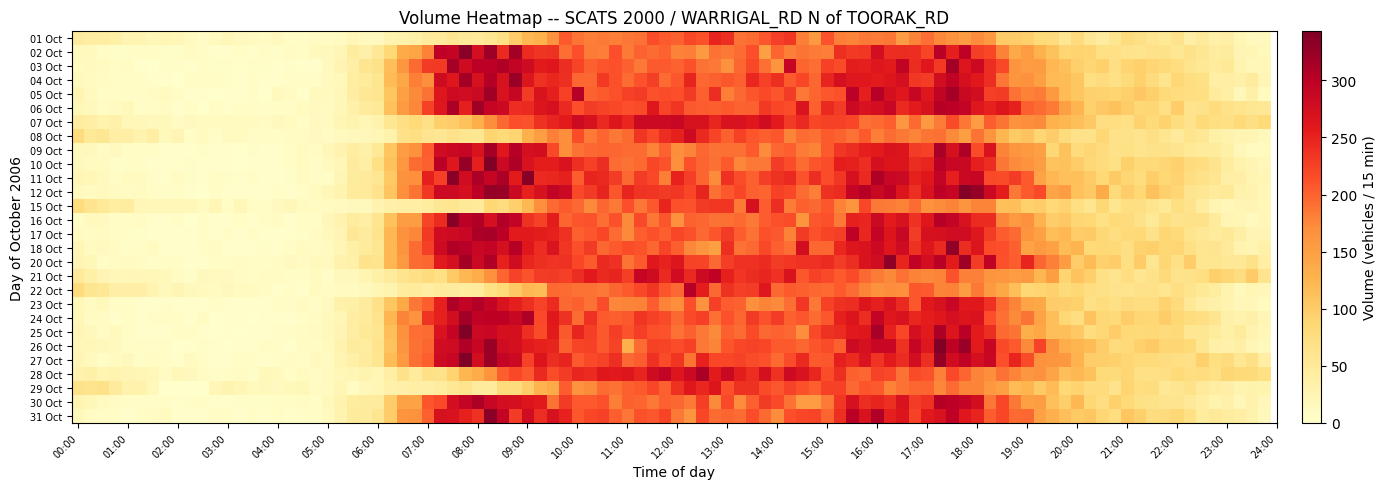

Heatmap: 28 days x 96 intervals


In [18]:
# 6.3 Heatmap: rows = day, columns = 96 intervals
pivot_heat = approach_long.pivot_table(
    index="date",
    columns="interval",
    values="volume",
    aggfunc="first",
)
pivot_heat.index = pd.to_datetime(pivot_heat.index).strftime("%d %b")

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    pivot_heat.values,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("Volume (vehicles / 15 min)")

ax.set_yticks(range(len(pivot_heat.index)))
ax.set_yticklabels(pivot_heat.index, fontsize=7)

hour_ticks = list(range(0, N_INTERVALS + 1, 4))
ax.set_xticks(hour_ticks)
ax.set_xticklabels(
    [f"{h // 4:02d}:00" for h in hour_ticks],
    rotation=45, ha="right", fontsize=7,
)
ax.set_xlabel("Time of day")
ax.set_ylabel("Day of October 2006")
ax.set_title(f"Volume Heatmap -- SCATS {TARGET_SCATS} / {TARGET_LOCATION}")
fig.tight_layout()
plt.savefig(PROCESSED_DIR / "plot_heatmap.png", dpi=120)
plt.show()
print(f"Heatmap: {pivot_heat.shape[0]} days x {pivot_heat.shape[1]} intervals")

---
## 7. Train / Val / Test Split Helper

**Assumption:** Traffic volume is a time series — shuffling leaks future data into  
training.  Splits are strictly chronological: earliest observations go to train, latest to test.

Default fractions for ~31 days of 15-minute data:
- **Train:** first ~21 days (70 %)
- **Val:**   next ~5 days (15 %)
- **Test:**  final ~5 days (15 %)

In [19]:
def make_splits(
    series: np.ndarray,
    train_frac: float = 0.70,
    val_frac: float   = 0.15,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Split a 1-D time series chronologically into train / val / test arrays.

    No shuffling is performed.  Shuffling a time series leaks future
    observations into training and produces optimistic, unrealistic metrics.

    Args:
        series:     1-D numpy array of ordered observations.
        train_frac: Fraction for training  (default 0.70 -> ~21 days).
        val_frac:   Fraction for validation (default 0.15 -> ~5 days).
                    Test fraction is 1 - train_frac - val_frac.

    Returns:
        (train_arr, val_arr, test_arr) as numpy arrays.

    Raises:
        ValueError: If fractions are invalid or series is not 1-D.
    """
    if series.ndim != 1:
        raise ValueError(f"series must be 1-D, got shape {series.shape}")
    if train_frac + val_frac >= 1.0:
        raise ValueError(
            f"train_frac + val_frac must be < 1.0, got {train_frac + val_frac:.3f}"
        )
    n = len(series)
    train_end = int(n * train_frac)
    val_end   = int(n * (train_frac + val_frac))
    return series[:train_end], series[train_end:val_end], series[val_end:]


example_values = demo_series.dropna().values
train_arr, val_arr, test_arr = make_splits(example_values)

total = len(example_values)
print(f"Series length: {total} intervals ({total / N_INTERVALS:.1f} days)")
print(f"  Train: {len(train_arr):>5}  ({len(train_arr) / N_INTERVALS:.1f} days)")
print(f"  Val:   {len(val_arr):>5}  ({len(val_arr) / N_INTERVALS:.1f} days)")
print(f"  Test:  {len(test_arr):>5}  ({len(test_arr) / N_INTERVALS:.1f} days)")
assert len(train_arr) + len(val_arr) + len(test_arr) == total

Series length: 2976 intervals (31.0 days)
  Train:  2083  (21.7 days)
  Val:     446  (4.6 days)
  Test:    447  (4.7 days)


---
## 8. Sliding-Window Helper

Converts a 1-D volume series into supervised `(X, y)` arrays for sequence models  
(LSTM, GRU, etc.).

- `lookback = 12` -> 3 hours of history (12 x 15 min) as model input
- `horizon  = 1`  -> predict the next single 15-minute interval

In [20]:
def make_windows(
    series: np.ndarray,
    lookback: int = 12,
    horizon:  int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert a 1-D time series into sliding-window (X, y) arrays.

    Each sample uses `lookback` consecutive observations as features and
    `horizon` subsequent observations as targets.  Windows advance one step
    at a time (stride = 1).

    Args:
        series:   1-D numpy array of ordered observations.  Should not
                  contain NaN values -- call .dropna() first if needed.
        lookback: Number of past intervals used as model input.
                  Default 12 = 3 hours at 15-minute resolution.
                  Increase for longer-range models (e.g. 96 for one full day).
        horizon:  Number of future intervals to predict.  Default 1 = the
                  next 15-minute interval.  Increase for multi-step forecasts.

    Returns:
        Tuple (X, y) where:
            X.shape == (n_samples, lookback)
            y.shape == (n_samples, horizon)
        n_samples = len(series) - lookback - horizon + 1

    Raises:
        ValueError: If series is not 1-D or too short for lookback + horizon.
    """
    if series.ndim != 1:
        raise ValueError(f"series must be 1-D, got shape {series.shape}")
    if len(series) < lookback + horizon:
        raise ValueError(
            f"series length {len(series)} < lookback+horizon={lookback + horizon}"
        )
    n_samples = len(series) - lookback - horizon + 1
    x_list = [series[i : i + lookback]                  for i in range(n_samples)]
    y_list = [series[i + lookback : i + lookback + horizon] for i in range(n_samples)]
    return np.array(x_list), np.array(y_list)


X_demo, y_demo = make_windows(train_arr, lookback=12, horizon=1)
print("make_windows demo (lookback=12, horizon=1):")
print(f"  Input length: {len(train_arr)}")
print(f"  X.shape: {X_demo.shape}   (n_samples, lookback)")
print(f"  y.shape: {y_demo.shape}   (n_samples, horizon)")
print(f"  X[0]: {X_demo[0]}")
print(f"  y[0]: {y_demo[0]}")

make_windows demo (lookback=12, horizon=1):
  Input length: 2083
  X.shape: (2071, 12)   (n_samples, lookback)
  y.shape: (2071, 1)   (n_samples, horizon)
  X[0]: [86. 83. 52. 58. 59. 44. 31. 37. 30. 24. 16. 24.]
  y[0]: [25.]


---
## 9. Save Outputs

Three artefacts written to `../data/processed/`:

| File | Description |
|---|---|
| `scats_long.parquet` | Long-format DataFrame -- canonical input for all downstream tasks |
| `scats_wide.parquet` | Wide per-approach DataFrame -- direct ML input |
| `scats_metadata.csv` | One row per approach with coordinate and volume summary stats |

In [21]:
# Build metadata table: one row per (scats_number, location) approach
meta_agg = (
    long_df.groupby(["scats_number", "location", "latitude", "longitude"])
    .agg(total_volume=("volume", "sum"))
    .reset_index()
)

days_lookup = days_per_approach.reset_index()
days_lookup.columns = ["scats_number", "location", "n_days"]
days_lookup["scats_number"] = days_lookup["scats_number"].astype(int)

metadata_df = meta_agg.merge(days_lookup, on=["scats_number", "location"], how="left")
metadata_df["mean_daily_volume"] = (
    metadata_df["total_volume"] / metadata_df["n_days"]
).round(2)

metadata_df = metadata_df[
    ["scats_number", "location", "latitude", "longitude",
     "n_days", "mean_daily_volume"]
].sort_values(["scats_number", "location"]).reset_index(drop=True)

print(f"Metadata rows: {len(metadata_df)}  (expected {EXPECTED_APPROACHES})")
metadata_df.head(5)

Metadata rows: 140  (expected 139)


,scats_number,location,latitude,longitude,n_days,mean_daily_volume
0,970,HIGH STREET_RD E of WARRIGAL_RD,-37.86735,145.09195,31,9554.94
1,970,HIGH STREET_RD W of WARRIGAL_RD,-37.86723,145.09103,30,11073.27
2,970,WARRIGAL_RD N of HIGH STREET_RD,-37.86703,145.09159,31,18129.68
3,970,WARRIGAL_RD S of HIGH STREET_RD,-37.86760,145.09146,31,17693.52
4,2000,BURWOOD_HWY E of WARRIGAL_RD,-37.85193,145.09463,29,15181.76


In [22]:
# Parquet requires serialisable types: convert date and time_of_day to str.
long_save = long_df.copy()
long_save["date"]        = long_save["date"].astype(str)
long_save["time_of_day"] = long_save["time_of_day"].astype(str)

long_save.to_parquet(PROCESSED_DIR / "scats_long.parquet", index=False)
wide_df.to_parquet(PROCESSED_DIR / "scats_wide.parquet")
metadata_df.to_csv(PROCESSED_DIR / "scats_metadata.csv", index=False)

print("Artefacts written:")
for fpath in sorted(PROCESSED_DIR.iterdir()):
    if fpath.suffix in (".parquet", ".csv"):
        size_kb = fpath.stat().st_size / 1024
        print(f"  {fpath.name:<32} {size_kb:>8.1f} KB")

Artefacts written:
  scats_long.parquet                  823.8 KB
  scats_metadata.csv                    9.0 KB
  scats_wide.parquet                  701.8 KB


In [23]:
# Round-trip verification
rt_long = pd.read_parquet(PROCESSED_DIR / "scats_long.parquet")
rt_wide = pd.read_parquet(PROCESSED_DIR / "scats_wide.parquet")
rt_meta = pd.read_csv(PROCESSED_DIR / "scats_metadata.csv")

assert rt_long.shape == long_save.shape,   "scats_long round-trip shape mismatch"
assert rt_wide.shape == wide_df.shape,     "scats_wide round-trip shape mismatch"
assert rt_meta.shape == metadata_df.shape, "scats_metadata round-trip shape mismatch"

print("Round-trip verification:")
print(f"  scats_long.parquet  {rt_long.shape}   OK")
print(f"  scats_wide.parquet  {rt_wide.shape}   OK")
print(f"  scats_metadata.csv  {rt_meta.shape}   OK")
print("\nAll artefacts verified. Notebook complete.")

Round-trip verification:
  scats_long.parquet  (402432, 9)   OK
  scats_wide.parquet  (2976, 139)   OK
  scats_metadata.csv  (140, 6)   OK

All artefacts verified. Notebook complete.
